In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
import pingouin as pg
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.multivariate.manova import MANOVA

In [2]:
df = pd.read_csv("all_seasons.csv")
df.head()

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [3]:
df.shape

(12844, 22)

In [4]:
df = df.drop(columns=['Unnamed: 0','oreb_pct',"dreb_pct","usg_pct","ast_pct"])


In [5]:
df.describe

<bound method NDFrame.describe of             player_name team_abbreviation   age  player_height  player_weight  \
0      Randy Livingston               HOU  22.0         193.04      94.800728   
1      Gaylon Nickerson               WAS  28.0         190.50      86.182480   
2          George Lynch               VAN  26.0         203.20     103.418976   
3        George McCloud               LAL  30.0         203.20     102.058200   
4          George Zidek               DEN  23.0         213.36     119.748288   
...                 ...               ...   ...            ...            ...   
12839       Joel Embiid               PHI  29.0         213.36     127.005760   
12840   John Butler Jr.               POR  20.0         213.36      86.182480   
12841      John Collins               ATL  25.0         205.74     102.511792   
12842      Jericho Sims               NYK  24.0         208.28     113.398000   
12843    JaMychal Green               GSW  33.0         205.74     102.9653

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_name        12844 non-null  object 
 1   team_abbreviation  12844 non-null  object 
 2   age                12844 non-null  float64
 3   player_height      12844 non-null  float64
 4   player_weight      12844 non-null  float64
 5   college            10990 non-null  object 
 6   country            12844 non-null  object 
 7   draft_year         12844 non-null  object 
 8   draft_round        12844 non-null  object 
 9   draft_number       12844 non-null  object 
 10  gp                 12844 non-null  int64  
 11  pts                12844 non-null  float64
 12  reb                12844 non-null  float64
 13  ast                12844 non-null  float64
 14  net_rating         12844 non-null  float64
 15  ts_pct             12844 non-null  float64
 16  season             128

In [7]:
df.tail(10)

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,gp,pts,reb,ast,net_rating,ts_pct,season
12834,Jimmy Butler,MIA,33.0,200.66,104.326160,Marquette,USA,2011,1,30,64,22.9,5.9,5.3,1.2,0.647,2022-23
12835,Jock Landale,PHX,27.0,210.82,115.665960,St. Mary's,Australia,Undrafted,Undrafted,Undrafted,69,6.6,4.1,1.0,7.9,0.595,2022-23
12836,Joe Harris,BKN,31.0,198.12,99.790240,Virginia,USA,2014,2,33,74,7.6,2.2,1.4,-1.0,0.621,2022-23
12837,Joe Ingles,MIL,35.0,205.74,99.790240,NaN,Australia,Undrafted,Undrafted,Undrafted,46,6.9,2.8,3.3,2.5,0.616,2022-23
12838,Joe Wieskamp,TOR,23.0,198.12,92.986360,Iowa,USA,2021,2,41,9,1.0,0.4,0.3,1.0,0.321,2022-23
12839,Joel Embiid,PHI,29.0,213.36,127.005760,Kansas,Cameroon,2014,1,3,66,33.1,10.2,4.2,8.8,0.655,2022-23
12840,John Butler Jr.,POR,20.0,213.36,86.182480,Florida State,USA,Undrafted,Undrafted,Undrafted,19,2.4,0.9,0.6,-16.1,0.411,2022-23
12841,John Collins,ATL,25.0,205.74,102.511792,Wake Forest,USA,2017,1,19,71,13.1,6.5,1.2,-0.2,0.593,2022-23
12842,Jericho Sims,NYK,24.0,208.28,113.398000,Texas,USA,2021,2,58,52,3.4,4.7,0.5,-6.7,0.780,2022-23
12843,JaMychal Green,GSW,33.0,205.74,102.965384,Alabama,USA,Undrafted,Undrafted,Undrafted,57,6.4,3.6,0.9,-8.2,0.650,2022-23


In [8]:
df["team_abbreviation"].unique()

array(['HOU', 'WAS', 'VAN', 'LAL', 'DEN', 'ORL', 'CHH', 'MIL', 'DET',
       'POR', 'DAL', 'UTA', 'SEA', 'BOS', 'IND', 'SAS', 'MIA', 'ATL',
       'NJN', 'LAC', 'GSW', 'PHI', 'NYK', 'TOR', 'PHX', 'MIN', 'CHI',
       'SAC', 'CLE', 'MEM', 'NOH', 'CHA', 'NOK', 'OKC', 'BKN', 'NOP'],
      dtype=object)

In [9]:
df.loc[
    (df["team_abbreviation"] == "NJN") | (df["team_abbreviation"] == "BKN"),
    "team_abbreviation"
] = "NJN -> BKN"

df.loc[
    (df["team_abbreviation"] == "OKC") | (df["team_abbreviation"] == "SEA"),
    "team_abbreviation"
] = "SEA -> OKC"

df.loc[
    (df["team_abbreviation"] == "VAN") | (df["team_abbreviation"] == "MEM"),
    "team_abbreviation"
] = "VAN -> MEM"

df.loc[
    (df["team_abbreviation"] == "CHH") | (df["team_abbreviation"] == "NOH") | (df["team_abbreviation"] == "NOK") | (df["team_abbreviation"] == "NOP"),
    "team_abbreviation"
] = "CHH -> NOH -> NOK -> NOP"

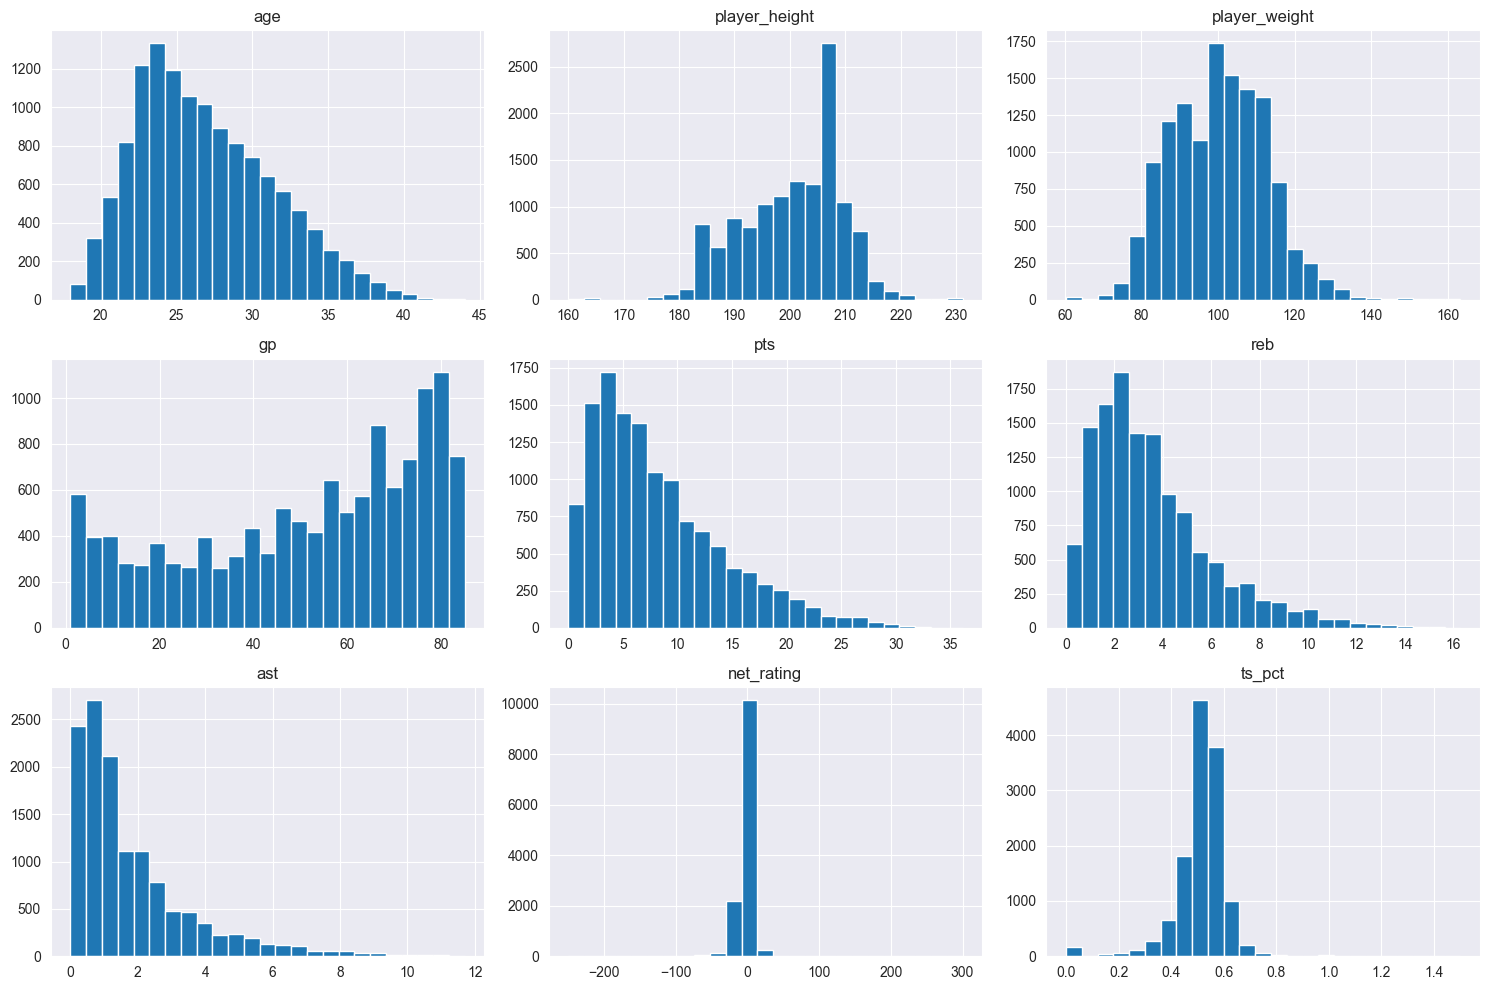

In [10]:
num_cols = ["age","player_height","player_weight","gp","pts","reb","ast","net_rating","ts_pct"]
df[num_cols].hist(bins=25, figsize=(15,10))
plt.tight_layout()
plt.show()

In [11]:
df = df[df["gp"] >= 10]

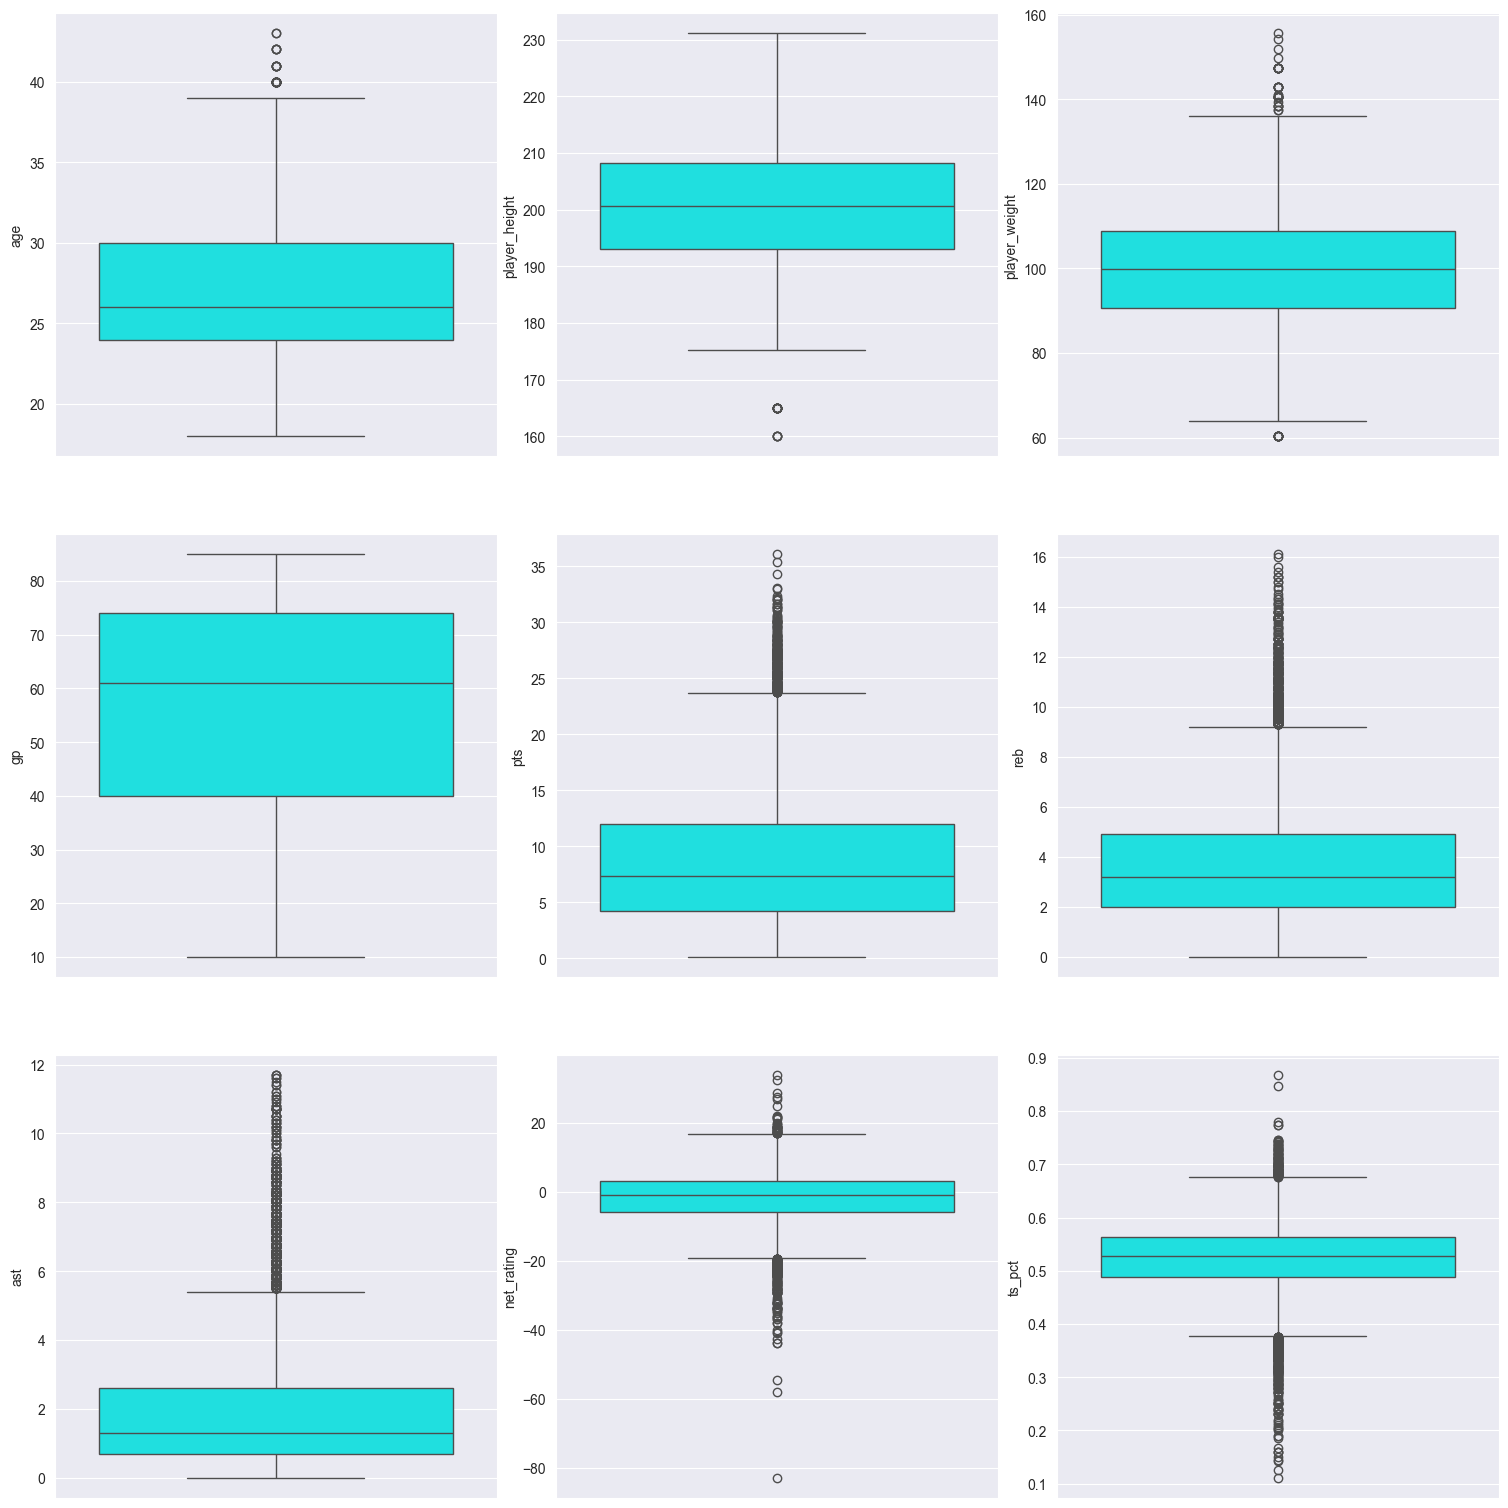

In [12]:
fig, axs = plt.subplots(ncols=3,nrows=3,figsize=(15,15))
index = 0
axs = axs.flatten()
for k,v in df[num_cols].items():
    sns.boxplot(y=k, data=df, ax =axs[index], color="cyan")
    index += 1
    plt.tight_layout(pad=0.4, w_pad=0.4, h_pad=5.4)

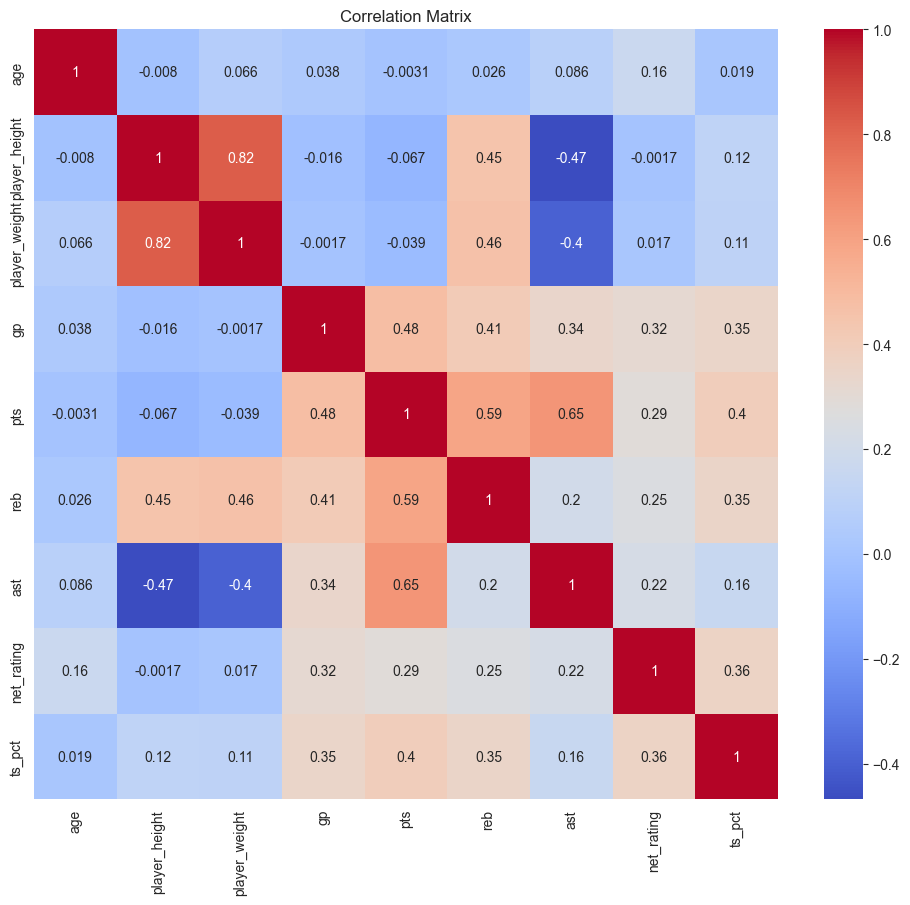

In [13]:
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

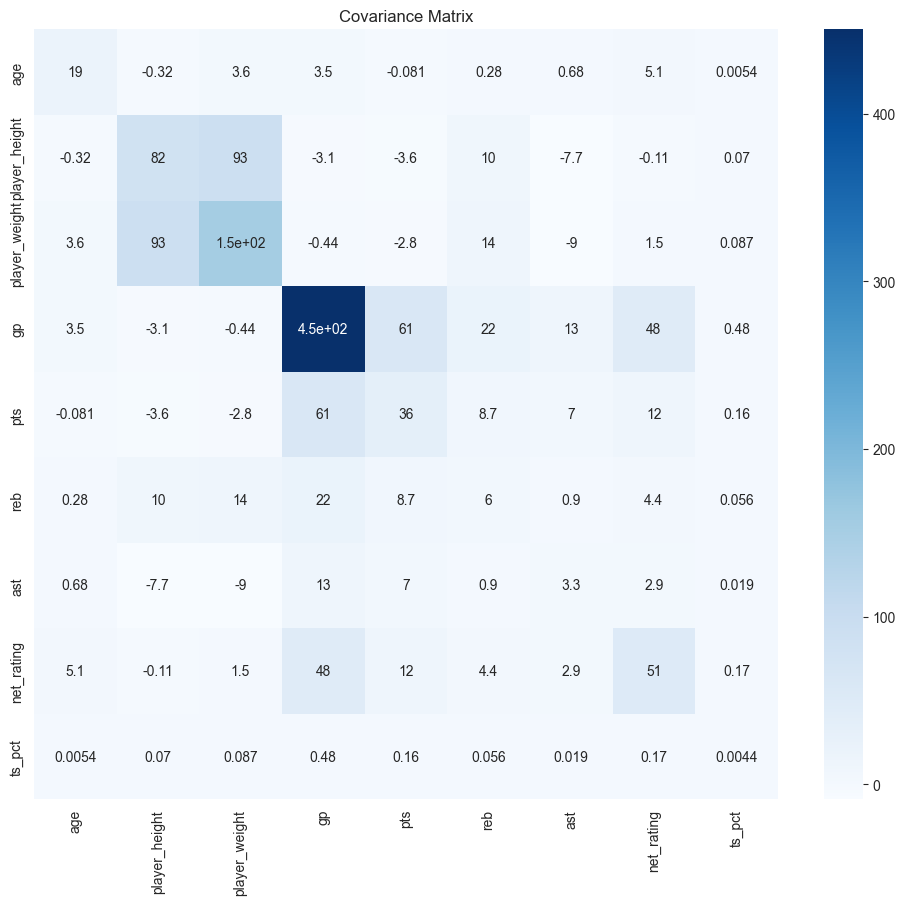

In [14]:
cov_matrix = df[num_cols].cov()
plt.figure(figsize=(12,10))
sns.heatmap(cov_matrix, annot=True, cmap="Blues")
plt.title("Covariance Matrix")
plt.show()

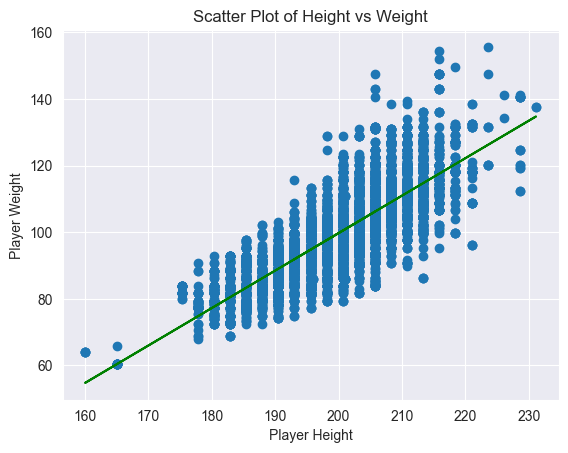

In [15]:
plt.scatter(df["player_height"], df["player_weight"])

m,b = np.polyfit(df["player_height"], df["player_weight"], 1)

plt.plot(df["player_height"], df["player_height"]*m+b, color = "green")
plt.xlabel("Player Height")
plt.ylabel("Player Weight")
plt.title("Scatter Plot of Height vs Weight")
plt.show()

In [16]:
hz_stat, p_value, normal = pg.multivariate_normality(df[num_cols])
print(f"HZ Statistic: {float(hz_stat)}")
print(f"P-Value: {float(p_value)}")
print(f"Normality: {normal}")

HZ Statistic: 5.07635020476071
P-Value: 0.0
Normality: False


Тестът ни връща отрицателна стойност

In [17]:
mean_vec = df[num_cols].mean().values
cov_matrix = np.cov(df[num_cols].values, rowvar = False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

def mahalanobis(x, mean, inv_cov):
    diff = x - mean
    return np.sqrt(diff.T @ inv_cov @ diff)

df.loc[:, "mahalanobis"] = df[num_cols].apply(lambda row: mahalanobis(row.values, mean_vec, inv_cov_matrix), axis=1)

alpha = 0.01
threshold = np.sqrt(chi2.ppf((1-alpha), df[num_cols].shape[1]))

outliers = df[df["mahalanobis"] > threshold]

top10 = outliers.nlargest(10, "mahalanobis")
print(top10)

          player_name team_abbreviation   age  player_height  player_weight  \
5558          Sun Sun               LAL  23.0         205.74       92.98636   
1712    Dennis Rodman               DAL  39.0         200.66       95.25432   
188     Dennis Rodman               CHI  36.0         198.12       99.79024   
1706       Ira Bowman               PHI  27.0         195.58       88.45044   
11487  Udoka Azubuike               UTA  21.0         208.28      127.00576   
760     Dennis Rodman               CHI  37.0         198.12       99.79024   
9018     Luis Montero               POR  23.0         200.66       83.91452   
342      Mark Jackson               IND  32.0         190.50       83.91452   
2948      Ben Wallace               DET  28.0         205.74      108.86208   
925     Dennis Rodman               LAL  38.0         200.66       95.25432   

                           college             country draft_year draft_round  \
5558                           NaN               

C:\Users\m.stefanov\AppData\Local\Temp\ipykernel_26896\2212274677.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "mahalanobis"] = df[num_cols].apply(lambda row: mahalanobis(row.values, mean_vec, inv_cov_matrix), axis=1)


In [38]:
stats_cols = ["gp","pts","reb","ast","net_rating","ts_pct"]
draft_df = df[(df["draft_round"] == "1") | (df["draft_round"] == "2") | (df["draft_round"] == "Undrafted")]

X = draft_df[stats_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=draft_df.index)
print(pca_df.head())



         PC1        PC2
0   7.348156  -1.002895
2 -15.351468  -3.947271
3   7.944501  -2.155310
4  -6.336015 -13.151213
5  23.313166  -7.533838


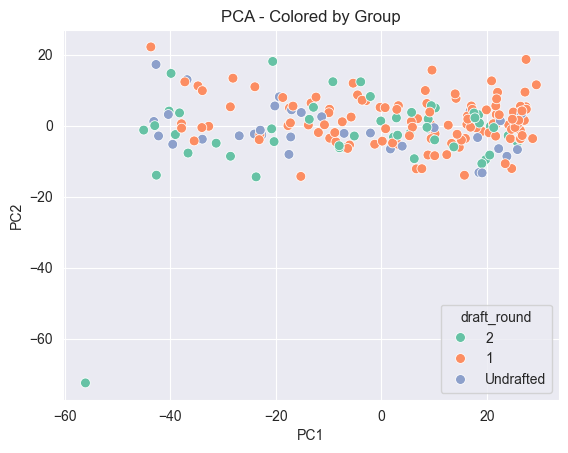

In [42]:
sample_pca = pca_df.sample(n=200)

sns.scatterplot(
    x='PC1', y='PC2',
    data=sample_pca.join(df["draft_round"]),
    hue='draft_round',
    palette='Set2',
    s=50
)
plt.title('PCA - Colored by Group')
plt.show()

In [46]:
manova = MANOVA.from_formula(
    "pts + reb ~ draft_round",
    data = draft_df
)

print(manova.mv_test())

                    Multivariate linear model
                                                                  
------------------------------------------------------------------
       Intercept        Value  Num DF   Den DF    F Value   Pr > F
------------------------------------------------------------------
          Wilks' lambda 0.2674 2.0000 11610.0000 15906.0697 0.0000
         Pillai's trace 0.7326 2.0000 11610.0000 15906.0697 0.0000
 Hotelling-Lawley trace 2.7401 2.0000 11610.0000 15906.0697 0.0000
    Roy's greatest root 2.7401 2.0000 11610.0000 15906.0697 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
        draft_round       Value  Num DF   Den DF   F Value  Pr > F
------------------------------------------------------------------
            Wilks' lambda 0.8606 4.0000 23220.0000 452.4830 0.0000
           Pilla